In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, PolynomialFeatures, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [2]:
df= pd.read_csv('D:\\shubham\\House prediction ML\\Bengaluru_House_Data.csv')
print("Data loaded successfully!")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())


Data loaded successfully!
(13320, 9)
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     1332

In [3]:
print("Sample 'size' values:", df['size'].dropna().head().unique()[:10])
def extract_bhk(size):
    if pd.isna(size):
        return np.nan
    size = str(size).lower()
    if 'bhk' in size or 'bedroom' in size:
        try:
            return int(''.join(filter(str.isdigit, size)))
        except:
            return np.nan
    return np.nan
df['bhk'] = df['size'].apply(extract_bhk)

def clean_sqft(x):
    if isinstance(x, str):
        if '-' in x:
            try:
                low, high = map(float, x.split('-'))
                return (low + high) / 2
            except:
                return np.nan
        try:
            return float(x)
        except:
            return np.nan
    return float(x)

df['total_sqft'] = df['total_sqft'].apply(clean_sqft)
print("BHK samples:", df['bhk'].dropna().head().tolist())
print("sqft samples:", df['total_sqft'].dropna().head().tolist())

Sample 'size' values: <StringArray>
['2 BHK', '4 Bedroom', '3 BHK']
Length: 3, dtype: str
BHK samples: [2.0, 4.0, 3.0, 3.0, 2.0]
sqft samples: [1056.0, 2600.0, 1440.0, 1521.0, 1200.0]


In [4]:
df['bath'] = pd.to_numeric(df['bath'], errors='coerce')
df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce').fillna(0)

df['has_balcony'] = (df['balcony'] > 0).astype(int)

print("All numeric cleaning done!")
print("\nFeature preview:")
preview_cols = ['bhk', 'total_sqft', 'bath', 'has_balcony', 'price']
print(df[preview_cols].head())
print("\nStats:")
print(df[preview_cols].describe())

All numeric cleaning done!

Feature preview:
   bhk  total_sqft  bath  has_balcony   price
0  2.0      1056.0   2.0            1   39.07
1  4.0      2600.0   5.0            1  120.00
2  3.0      1440.0   2.0            1   62.00
3  3.0      1521.0   3.0            1   95.00
4  2.0      1200.0   2.0            1   51.00

Stats:
                bhk    total_sqft          bath   has_balcony         price
count  13291.000000  13274.000000  13247.000000  13320.000000  13320.000000
mean       2.805507   1559.626694      2.692610      0.877027    112.565627
std        1.294377   1238.405258      1.341458      0.328419    148.971674
min        1.000000      1.000000      1.000000      0.000000      8.000000
25%        2.000000   1100.000000      2.000000      1.000000     50.000000
50%        3.000000   1276.000000      2.000000      1.000000     72.000000
75%        3.000000   1680.000000      3.000000      1.000000    120.000000
max       43.000000  52272.000000     40.000000      1.000000  

In [5]:
print("Before cleaning:", df.shape)

df = df.dropna(subset=['bhk', 'total_sqft', 'bath', 'price'])
print(f"After dropna: {df.shape}")

df = df[
    (df['price'] < 200) &
    (df['bhk'] < 20) &              
    (df['bath'] < 15) &              
    (df['total_sqft'] > 300) &      
    (df['total_sqft'] < 30000)  
]

print(f"After outlier removal: {df.shape}")
print("\nFinal dataset stats:")
print(df[['bhk', 'total_sqft', 'bath', 'price']].describe())

Before cleaning: (13320, 11)
After dropna: (13188, 11)
After outlier removal: (11630, 11)

Final dataset stats:
                bhk    total_sqft          bath         price
count  11630.000000  11630.000000  11630.000000  11630.000000
mean       2.616681   1342.994091      2.471281     76.021664
std        1.047876    604.078835      1.047743     38.672731
min        1.000000    302.000000      1.000000      9.000000
25%        2.000000   1075.000000      2.000000     47.590000
50%        2.000000   1230.000000      2.000000     65.000000
75%        3.000000   1530.000000      3.000000     95.000000
max       11.000000  26136.000000     13.000000    199.000000


area_type           str
availability        str
location            str
size                str
society             str
total_sqft      float64
bath            float64
balcony         float64
price           float64
bhk             float64
has_balcony       int64
dtype: object
Numeric columns: ['total_sqft', 'bath', 'balcony', 'price', 'bhk', 'has_balcony']


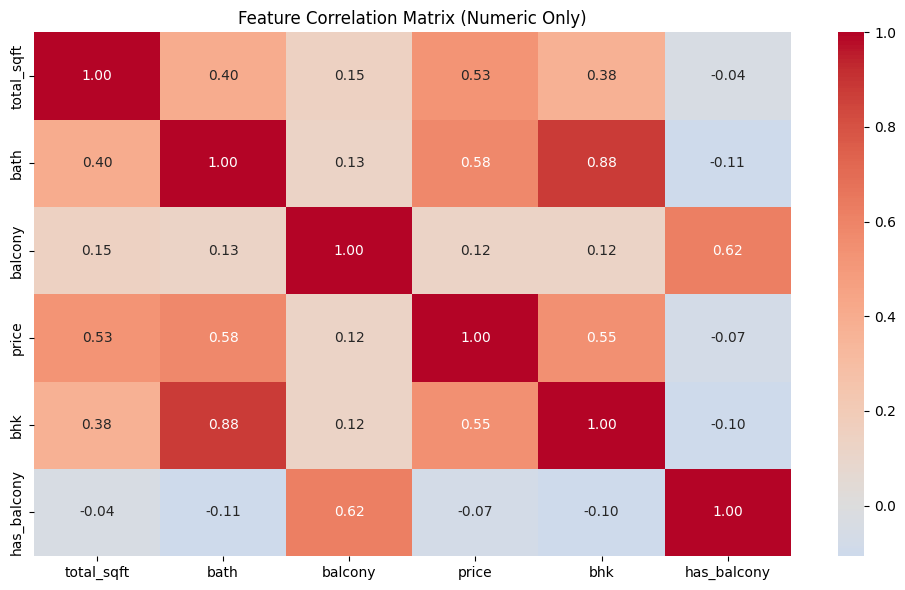


Strongest correlations with PRICE:
price          1.000
bath           0.581
bhk            0.546
total_sqft     0.529
balcony        0.125
has_balcony   -0.069
Name: price, dtype: float64


In [6]:
print(df.dtypes)
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric columns:", numeric_cols.tolist())
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix (Numeric Only)')
plt.tight_layout()
plt.show()

print("\nStrongest correlations with PRICE:")
price_corr = corr['price'].sort_values(ascending=False)
print(price_corr.round(3))

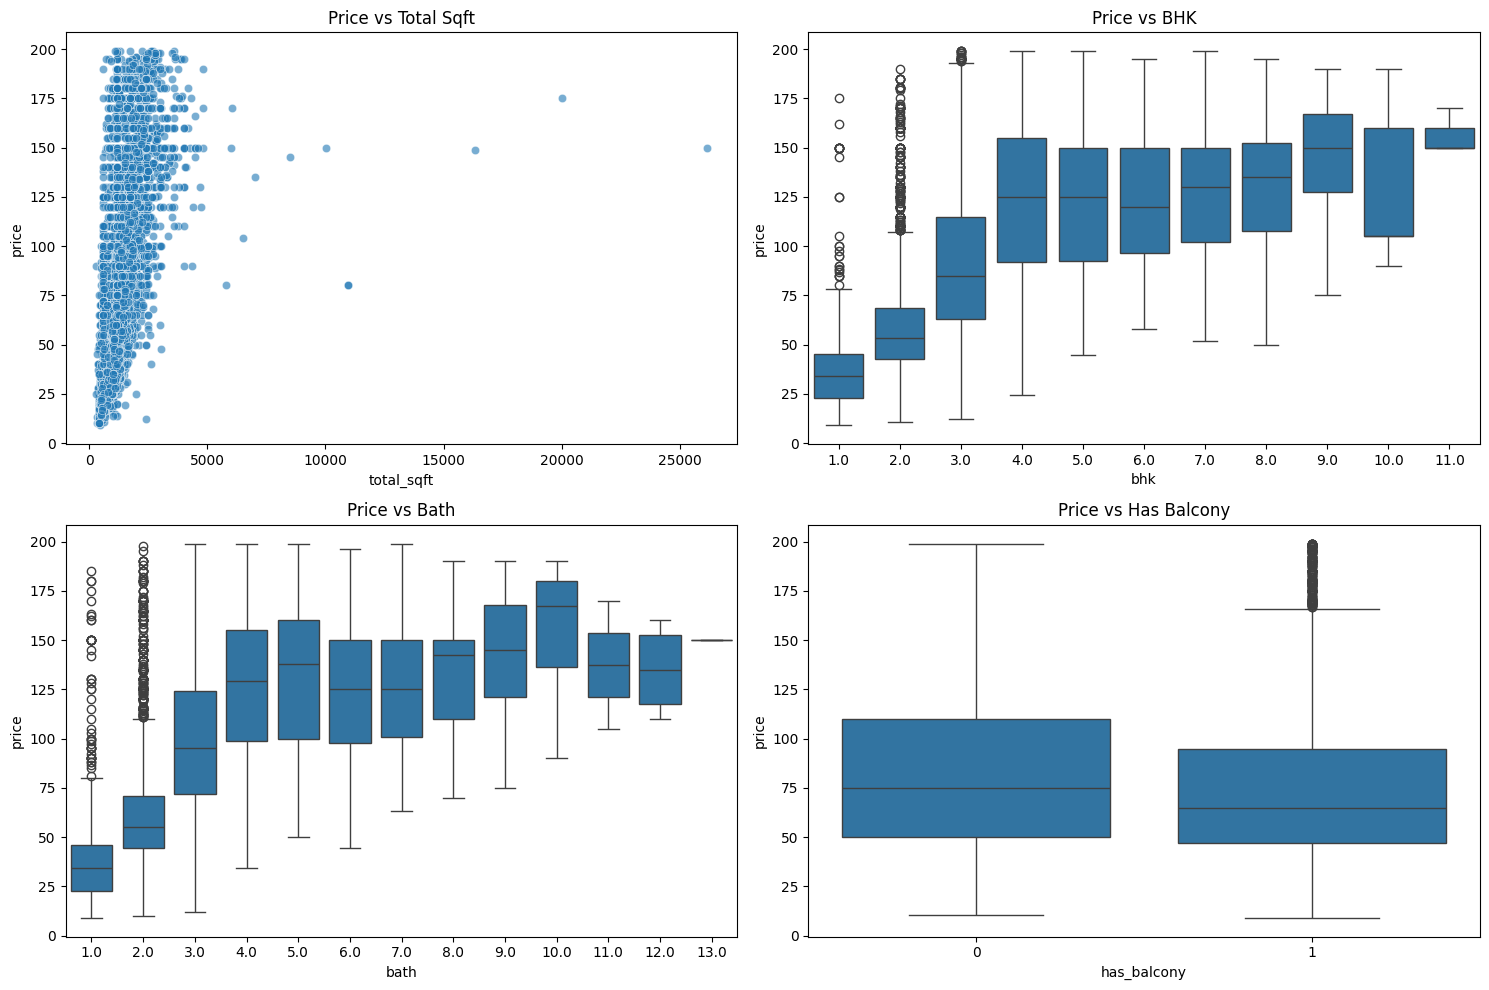

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.scatterplot(x='total_sqft', y='price', data=df, ax=axes[0,0], alpha=0.6)
axes[0,0].set_title('Price vs Total Sqft')

sns.boxplot(x='bhk', y='price', data=df, ax=axes[0,1])
axes[0,1].set_title('Price vs BHK')

sns.boxplot(x='bath', y='price', data=df, ax=axes[1,0])
axes[1,0].set_title('Price vs Bath')

sns.boxplot(x='has_balcony', y='price', data=df, ax=axes[1,1])
axes[1,1].set_title('Price vs Has Balcony')

plt.tight_layout()
plt.show()

In [8]:
# Create engineered features
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']
df['bath_per_bhk'] = df['bath'] / df['bhk']

print("Engineered features created!")
print(f"sqft_per_bhk range: {df['sqft_per_bhk'].min():.2f} - {df['sqft_per_bhk'].max():.2f}")
print(f"bath_per_bhk range: {df['bath_per_bhk'].min():.2f} - {df['bath_per_bhk'].max():.2f}")

Engineered features created!
sqft_per_bhk range: 66.67 - 26136.00
bath_per_bhk range: 0.25 - 2.00


In [9]:
X = df[['location', 'total_sqft', 'bhk', 'bath', 'has_balcony', 'sqft_per_bhk', 'bath_per_bhk']]
y = df['price']

print("Training features prepared!")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print("\nFeature columns:", X.columns.tolist())
print("\nTarget price range: ₹{:.1f}Lakh - ₹{:.1f}Lakh".format(y.min(), y.max()))

Training features prepared!
X shape: (11630, 7), y shape: (11630,)

Feature columns: ['location', 'total_sqft', 'bhk', 'bath', 'has_balcony', 'sqft_per_bhk', 'bath_per_bhk']

Target price range: ₹9.0Lakh - ₹199.0Lakh


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split completed!")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Data split completed!
Train: (9304, 7), Test: (2326, 7)


In [11]:
top_locations = X_train['location'].value_counts().head(100).index

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc['location'] = X_train_enc['location'].apply(lambda x: x if x in top_locations else 'other')
X_test_enc['location'] = X_test_enc['location'].apply(lambda x: x if x in top_locations else 'other')

print(f"Reduced locations: {X_train['location'].nunique()} → {X_train_enc['location'].nunique()}")

# One-hot encoding for location
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
location_train = ohe.fit_transform(X_train_enc[['location']])
location_test = ohe.transform(X_test_enc[['location']])
print("Location one-hot encoding completed!")
print(f"Location categories: {len(ohe.categories_[0])}")

# Polynomial features (degree 3) for numeric columns
num_features = ['total_sqft', 'bhk', 'bath', 'has_balcony', 'sqft_per_bhk', 'bath_per_bhk']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_num = poly.fit_transform(X_train_enc[num_features])
X_test_num = poly.transform(X_test_enc[num_features])
print(f"Polynomial features (degree 3): {len(num_features)} -> {X_train_num.shape[1]} features")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

# Combine polynomial features with location encoding
X_train_scaled = np.hstack([X_train_scaled, location_train])
X_test_scaled = np.hstack([X_test_scaled, location_test])
print("Feature scaling and combination completed!")
print(f"Final feature shape: {X_train_scaled.shape}")

Reduced locations: 1089 → 101


Location one-hot encoding completed!
Location categories: 101
Polynomial features (degree 3): 6 -> 83 features
Feature scaling and combination completed!
Final feature shape: (9304, 184)


In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Coefficients shape: {model.coef_.shape}")

Model trained successfully!
Coefficients shape: (184,)


In [13]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print("Predictions generated!")
print(f"Train predictions: {y_pred_train[:5]}")
print(f"Test predictions: {y_pred_test[:5]}")

Predictions generated!
Train predictions: [ 87.31703586 112.02066823  66.9157421   33.62865302  60.9874697 ]
Test predictions: [70.80111662 66.45799847 88.00374576 70.76109275 87.69092768]


In [14]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("PERFORMANCE METRICS")
print("="*40)
print(f"TRAIN - RMSE: {train_rmse:.2f} | R²: {train_r2:.4f}")
print(f"TEST  - RMSE: {test_rmse:.2f} | R²: {test_r2:.4f}")
print("\nMetrics calculated!")

PERFORMANCE METRICS
TRAIN - RMSE: 23.72 | R²: 0.6282
TEST  - RMSE: 24.19 | R²: 0.5882

Metrics calculated!


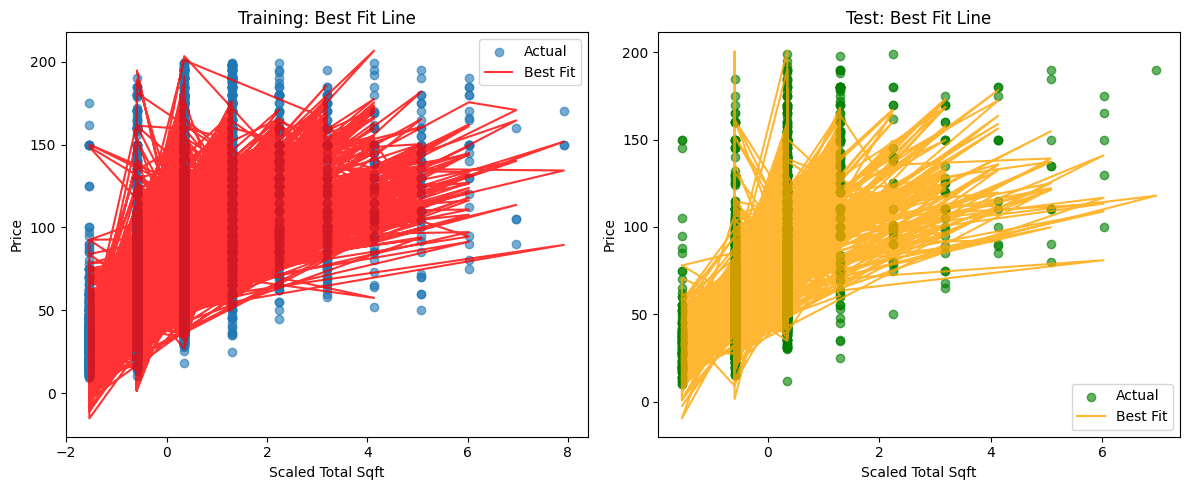

In [15]:
total_sqft_train = X_train_scaled[:, 1]
total_sqft_test = X_test_scaled[:, 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(total_sqft_train, y_train, alpha=0.6, label='Actual')
plt.plot(total_sqft_train, y_pred_train, color='red', alpha=0.8, label='Best Fit')
plt.xlabel('Scaled Total Sqft')
plt.ylabel('Price')
plt.title('Training: Best Fit Line')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(total_sqft_test, y_test, alpha=0.6, color='green', label='Actual')
plt.plot(total_sqft_test, y_pred_test, color='orange', alpha=0.8, label='Best Fit')
plt.xlabel('Scaled Total Sqft')
plt.ylabel('Price')
plt.title('Test: Best Fit Line')
plt.legend()

plt.tight_layout()
plt.show()

Analyzing residuals for model validation...


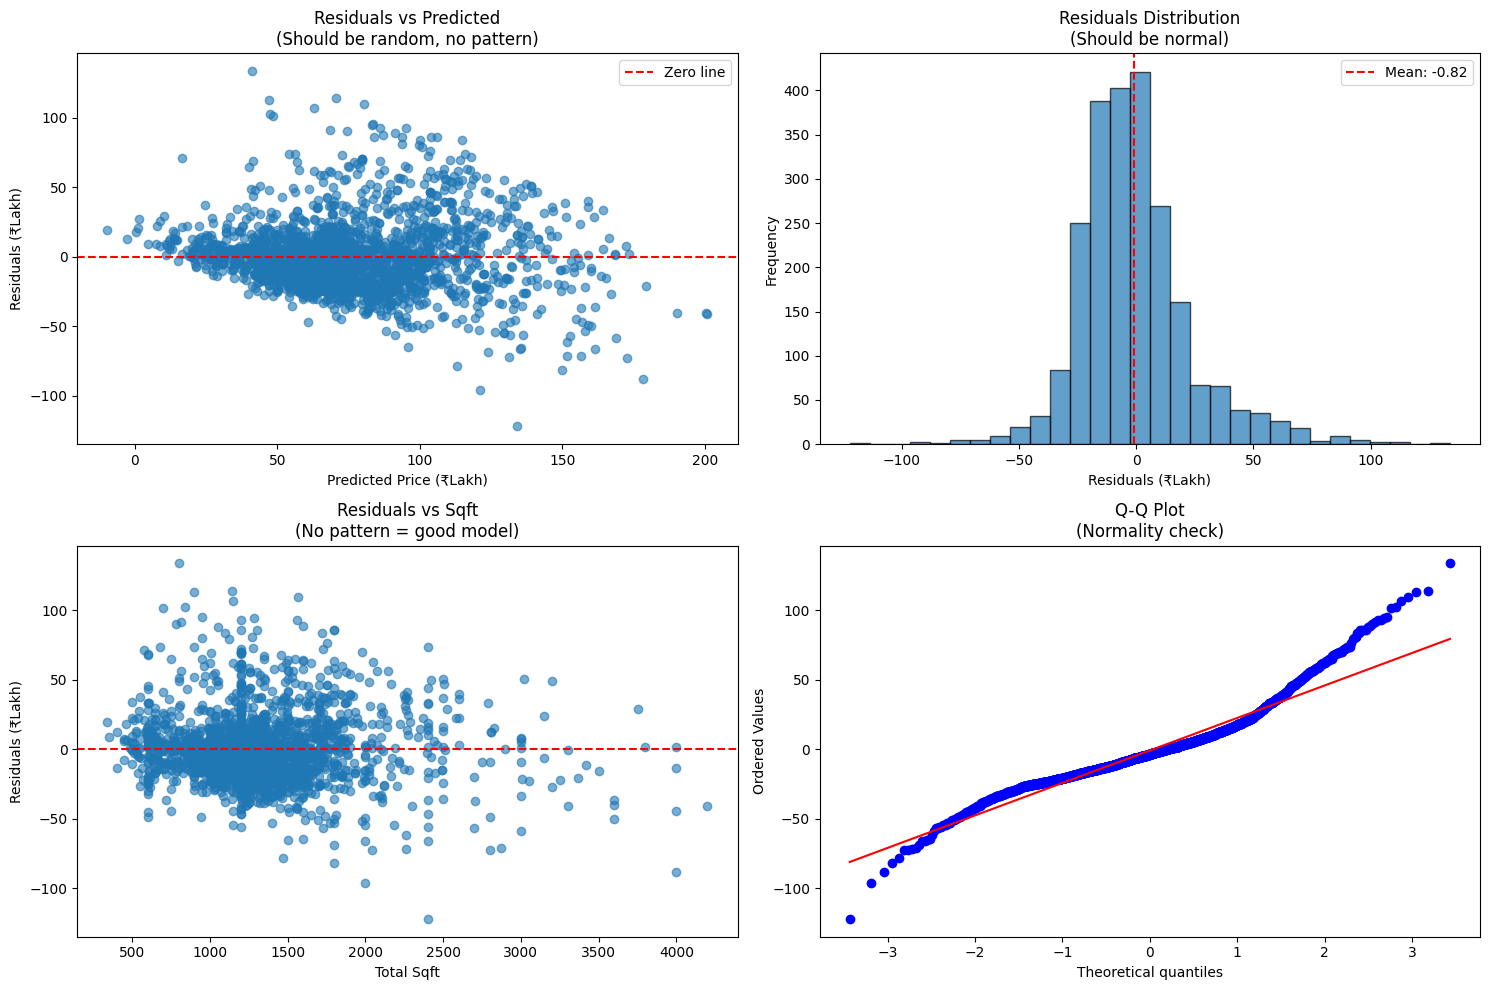

Residual Analysis COMPLETE!
Residuals Mean: -0.8176 (should be ~0)
Residuals Std:  24.1780
RMSE:           24.19 Lakh

INTERPRETATION:
-Mean ~0: Model unbiased
-Random scatter: Linear assumptions valid
-Normal histogram: Homoscedasticity OK
-Q-Q straight: Residuals normal


In [16]:
residuals_test = y_test - y_pred_test

print("Analyzing residuals for model validation...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].scatter(y_pred_test, residuals_test, alpha=0.6)
axes[0,0].axhline(y=0, color='red', linestyle='--', label='Zero line')
axes[0,0].set_xlabel('Predicted Price (₹Lakh)')
axes[0,0].set_ylabel('Residuals (₹Lakh)')
axes[0,0].set_title('Residuals vs Predicted\n(Should be random, no pattern)')
axes[0,0].legend()

axes[0,1].hist(residuals_test, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].axvline(residuals_test.mean(), color='red', linestyle='--', 
                  label=f'Mean: {residuals_test.mean():.2f}')
axes[0,1].set_xlabel('Residuals (₹Lakh)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Residuals Distribution\n(Should be normal)')
axes[0,1].legend()

total_sqft_test = X_test['total_sqft'].values 
axes[1,0].scatter(total_sqft_test, residuals_test, alpha=0.6)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_xlabel('Total Sqft')
axes[1,0].set_ylabel('Residuals (₹Lakh)')
axes[1,0].set_title('Residuals vs Sqft\n(No pattern = good model)')

from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot\n(Normality check)')

plt.tight_layout()
plt.show()
print("Residual Analysis COMPLETE!")
print(f"Residuals Mean: {residuals_test.mean():.4f} (should be ~0)")
print(f"Residuals Std:  {residuals_test.std():.4f}")
print(f"RMSE:           {np.sqrt((residuals_test**2).mean()):.2f} Lakh")
print("\nINTERPRETATION:")
print("-Mean ~0: Model unbiased")
print("-Random scatter: Linear assumptions valid") 
print("-Normal histogram: Homoscedasticity OK")
print("-Q-Q straight: Residuals normal")

In [ ]:
def predict_house_price(location, total_sqft, bhk, bath, balcony=0):
    input_df = pd.DataFrame({
        'location': [location],
        'total_sqft': [total_sqft],
        'bhk': [bhk],
        'bath': [bath],          
        'has_balcony': [1 if balcony > 0 else 0]
    })
    
    input_df['sqft_per_bhk'] = input_df['total_sqft'] / input_df['bhk']
    input_df['bath_per_bhk'] = input_df['bath'] / input_df['bhk']

    input_df['location'] = input_df['location'].apply(
        lambda x: x if x in top_locations else 'other'
    )
    
    location_encoded = ohe.transform(input_df[['location']])
    
    num_features = ['total_sqft', 'bhk', 'bath', 'has_balcony', 'sqft_per_bhk', 'bath_per_bhk']
    input_num = poly.transform(input_df[num_features])
    
    input_scaled = scaler.transform(input_num)
    
    input_scaled = np.hstack([input_scaled, location_encoded])
    
    price = model.predict(input_scaled)[0]
    return price
print("SAMPLE HOUSE PRICE PREDICTIONS:")
print("="*50)

p1 = predict_house_price('Whitefield', 1500, 3, 2, 1)
print(f"3BHK | 1500sqft | Whitefield | 2bath | Balcony → ₹{p1:.2f} Lakh")

p2 = predict_house_price('Electronic City Phase II', 1000, 2, 2, 0)
print(f"2BHK | 1000sqft | Electronic City | 2bath → ₹{p2:.2f} Lakh")

p3 = predict_house_price('Koramangala', 3000, 4, 4, 2)
print(f"4BHK | 3000sqft | Koramangala | 4bath | Balcony → ₹{p3:.2f} Lakh")

print("\nPrediction function working properly!")
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
print("FINAL PERFORMANCE METRICS")

SAMPLE HOUSE PRICE PREDICTIONS:
3BHK | 1500sqft | Whitefield | 2bath | Balcony → ₹74.89 Lakh
2BHK | 1000sqft | Electronic City | 2bath → ₹35.94 Lakh
4BHK | 3000sqft | Koramangala | 4bath | Balcony → ₹189.76 Lakh

Prediction function working properly!
FINAL PERFORMANCE METRICS


In [ ]:
import pickle
import os

model_components = {
    'model': model,
    'scaler': scaler,
    'ohe': ohe,
    'poly': poly,
    'top_locations': top_locations
}

model_path = 'house_model.pkl'
pickle.dump(model_components, open(model_path, 'wb'))
print(f"Model exported successfully to '{model_path}'!")
print(f"File size: {os.path.getsize(model_path) / (1024*1024):.2f} MB")

Model exported successfully to 'house_model.pkl'!
File size: 0.01 MB
